### Notebook 2: EDA, transformation, scoring artists, validation/exploration with K-Means

In [1]:
import duckdb as dd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
conn = dd.connect('spotify_all_years.db')

In [2]:
df = conn.execute("SELECT * FROM feature_engineered_table").df()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_metadata_album_artist_name  2733 non-null   object 
 1   play_count_per_artist              2733 non-null   int64  
 2   unique_albums_for_artist           2733 non-null   int64  
 3   num_unique_songs_for_artist        2733 non-null   int64  
 4   completion_rate                    2733 non-null   float64
 5   intentional_listening_rate         2733 non-null   float64
 6   skip_rate                          2733 non-null   float64
 7   listening_consistency              621 non-null    Int64  
 8   num_true_albums                    487 non-null    Int64  
 9   revisit_rate                       1106 non-null   Int64  
dtypes: Int64(3), float64(3), int64(3), object(1)
memory usage: 221.7+ KB


In [4]:
df.describe()

,play_count_per_artist,unique_albums_for_artist,num_unique_songs_for_artist,completion_rate,intentional_listening_rate,skip_rate,listening_consistency,num_true_albums,revisit_rate
count,2733.000000,2733.000000,2733.000000,2733.000000,2733.000000,2733.000000,621.0,487.0,1106.0
mean,36.953531,1.974753,2.819978,0.313547,0.271468,0.330306,8.15781,2.008214,2.34358
std,177.171345,2.457044,6.327374,0.339799,0.346676,0.379355,12.303588,1.87246,1.562988
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0
25%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0
50%,3.000000,1.000000,1.000000,0.250000,0.142857,0.163462,2.0,1.0,2.0
75%,16.000000,2.000000,2.000000,0.500000,0.357143,0.600000,10.0,2.0,3.0
max,4077.000000,34.000000,120.000000,1.000000,1.000000,1.000000,70.0,19.0,9.0


array([[<Axes: title={'center': 'play_count_per_artist'}>,
        <Axes: title={'center': 'unique_albums_for_artist'}>,
        <Axes: title={'center': 'num_unique_songs_for_artist'}>],
       [<Axes: title={'center': 'completion_rate'}>,
        <Axes: title={'center': 'intentional_listening_rate'}>,
        <Axes: title={'center': 'skip_rate'}>],
       [<Axes: title={'center': 'listening_consistency'}>,
        <Axes: title={'center': 'num_true_albums'}>,
        <Axes: title={'center': 'revisit_rate'}>]], dtype=object)

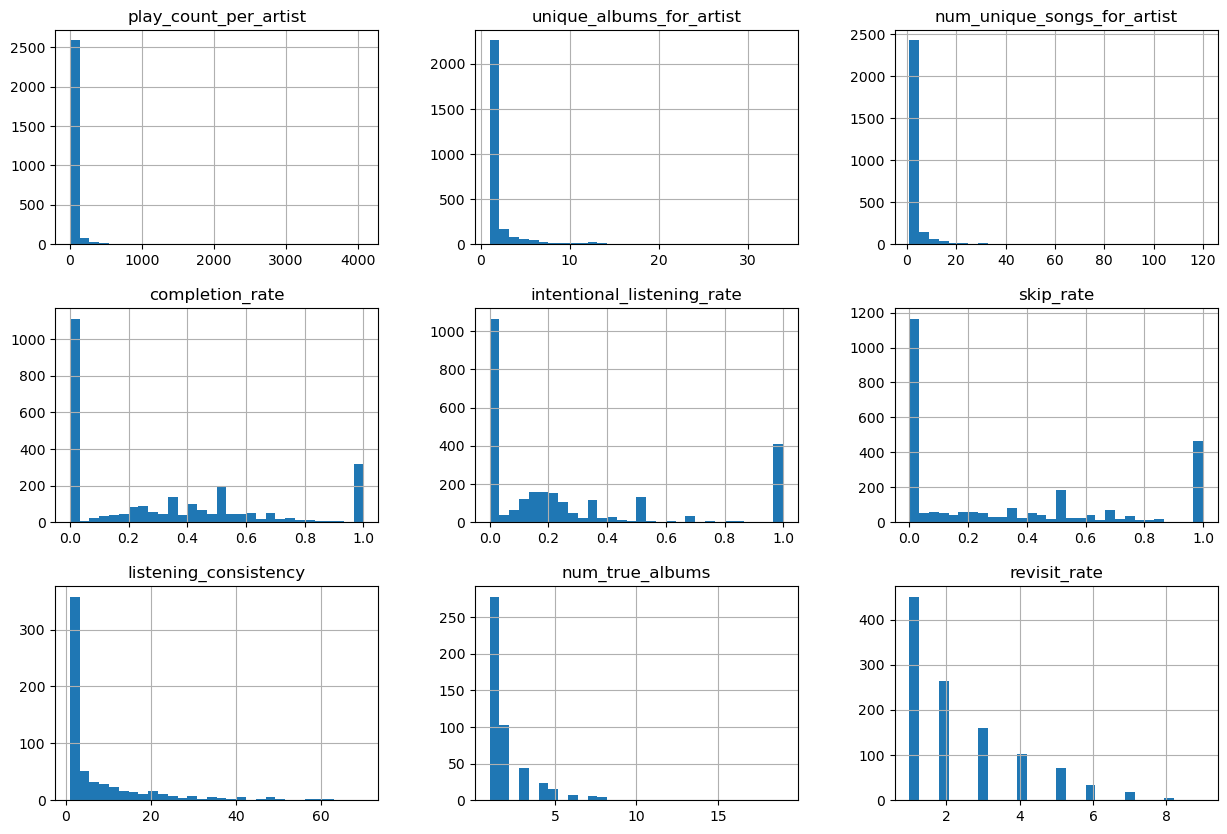

In [5]:
df.hist(bins=30, figsize=(15,10))

### Correlations amongst variables
- Pearson vs. Spearman.
- Pearson: assumes linearity and normal distribution of data, and is sensitive to outliers.

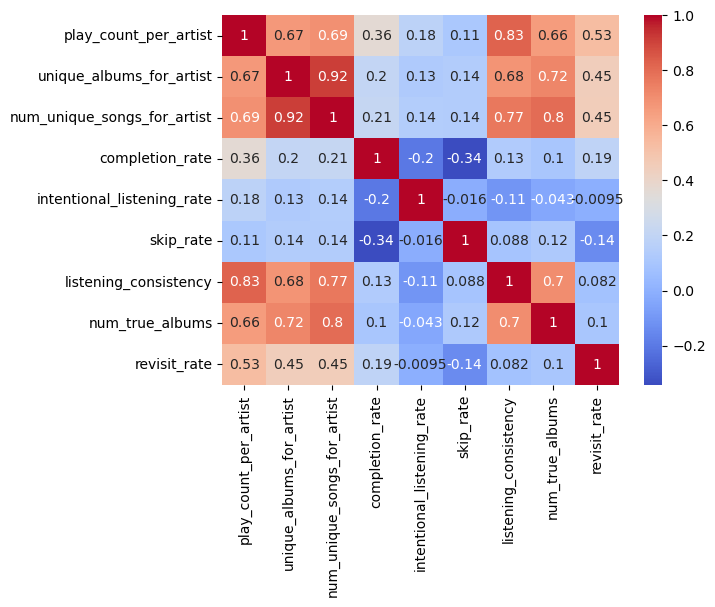

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop(columns=['master_metadata_album_artist_name']).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [7]:
df = df.drop(columns=['unique_albums_for_artist','skip_rate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_metadata_album_artist_name  2733 non-null   object 
 1   play_count_per_artist              2733 non-null   int64  
 2   num_unique_songs_for_artist        2733 non-null   int64  
 3   completion_rate                    2733 non-null   float64
 4   intentional_listening_rate         2733 non-null   float64
 5   listening_consistency              621 non-null    Int64  
 6   num_true_albums                    487 non-null    Int64  
 7   revisit_rate                       1106 non-null   Int64  
dtypes: Int64(3), float64(2), int64(2), object(1)
memory usage: 178.9+ KB


In [8]:
# Option 1: Min-max scale the raw features → build score → check top 20
from sklearn.preprocessing import MinMaxScaler
df_numeric = df.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_numeric)
scaled_df = pd.DataFrame(scaled_data, columns=df_numeric.columns)

In [ ]:
# basic scaling formula wih weights of how important that feature is to a superfan score (chosen on domain knowledge)
scaled_df['superfan_score'] = (
    0.20 * scaled_df['listening_consistency'] +
    0.20 * scaled_df['play_count_per_artist'] +
    0.20 * scaled_df['revisit_rate'] +
    0.15 * scaled_df['num_unique_songs_for_artist'] +
    0.10 * scaled_df['num_true_albums'] +
    0.10 * scaled_df['completion_rate'] +
    0.05 * scaled_df['intentional_listening_rate']
)
scaled_df['artist_name'] = df['master_metadata_album_artist_name'] #adding back the artist name
scaled_df.sort_values('superfan_score', ascending=False).head(20) #top 20 artists based on score

,play_count_per_artist,num_unique_songs_for_artist,completion_rate,intentional_listening_rate,listening_consistency,num_true_albums,revisit_rate,superfan_score,artist_name
149,1.000000,0.848739,0.363012,0.174148,0.840580,0.777778,0.250,0.668213,The Weeknd
68,0.460255,1.000000,0.295152,0.177944,0.927536,1.000000,0.125,0.590971,Drake
1944,0.853778,0.579832,0.511060,0.203677,0.942029,0.444444,0.000,0.551871,The Neighbourhood
1940,0.621688,0.621849,0.488363,0.219329,0.869565,0.666667,0.125,0.542997,Taylor Swift
1955,0.715653,0.512605,0.578478,0.143592,0.840580,0.388889,0.000,0.492054,Wallows
101,0.415358,0.579832,0.429752,0.195396,0.710145,0.222222,0.250,0.437043,Juice WRLD
40,0.474730,0.285714,0.521694,0.155992,1.000000,0.222222,0.000,0.419994,Clairo
1937,0.608685,0.428571,0.612409,0.126914,0.594203,0.333333,0.000,0.405783,Dominic Fike
58,0.207066,0.462185,0.448521,0.176331,0.855072,0.388889,0.125,0.399313,Ariana Grande
195,0.172718,0.252101,0.530496,0.208511,0.695652,0.166667,0.375,0.366631,Troye Sivan


In [ ]:
# Option 2: Log transformed variables → min-max scale → build score → top 20
df_with_log_variables = df.copy() #make copy of original df
for i in df.select_dtypes(include='number').columns:
    df_with_log_variables['log_' + i] = np.log1p(df[i]) #appended new log columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2733 entries, 0 to 2732
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_metadata_album_artist_name  2733 non-null   object 
 1   play_count_per_artist              2733 non-null   int64  
 2   num_unique_songs_for_artist        2733 non-null   int64  
 3   completion_rate                    2733 non-null   float64
 4   intentional_listening_rate         2733 non-null   float64
 5   listening_consistency              621 non-null    Int64  
 6   num_true_albums                    487 non-null    Int64  
 7   revisit_rate                       1106 non-null   Int64  
 8   log_play_count_per_artist          2733 non-null   float64
 9   log_num_unique_songs_for_artist    2733 non-null   float64
 10  log_completion_rate                2733 non-null   float64
 11  log_intentional_listening_rate     2733 non-null   float

In [ ]:
log_cols = [col for col in df_with_log_variables.columns if col.startswith('log_')] #only log columns
log_cols.append('master_metadata_album_artist_name') # addding back artist names
df_log_only = df_with_log_variables[log_cols] #log columns + artists = new df
from sklearn.preprocessing import MinMaxScaler
df_numeric = df_log_only.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_numeric)
scaled_df = pd.DataFrame(scaled_data, columns=df_numeric.columns) #new scaled df based on log transformed df

In [12]:
scaled_df['superfan_score'] = (
    0.30 * scaled_df['log_listening_consistency'] +
    0.15 * scaled_df['log_play_count_per_artist'] +
    0.15 * scaled_df['log_revisit_rate'] +
    0.15 * scaled_df['log_num_unique_songs_for_artist'] +
    0.10 * scaled_df['log_num_true_albums'] +
    0.10 * scaled_df['log_completion_rate'] +
    0.05 * scaled_df['log_intentional_listening_rate']
)
scaled_df['artist_name'] = df['master_metadata_album_artist_name']
scaled_df.sort_values('superfan_score', ascending=False).head(30)

,log_play_count_per_artist,log_num_unique_songs_for_artist,log_completion_rate,log_intentional_listening_rate,log_listening_consistency,log_num_true_albums,log_revisit_rate,superfan_score,artist_name
149,1.000000,0.960742,0.446798,0.231614,0.952841,0.903090,0.430677,0.791135,The Weeknd
68,0.898244,1.000000,0.373121,0.236270,0.979542,1.000000,0.251930,0.765514,Drake
1940,0.937663,0.886644,0.573726,0.286088,0.962027,0.845098,0.251930,0.756231,Taylor Swift
1944,0.979266,0.870057,0.595561,0.267448,0.983755,0.698970,0.000000,0.715350,The Neighbourhood
101,0.884790,0.870057,0.515765,0.257488,0.907312,0.477121,0.430677,0.712185,Juice WRLD
58,0.793596,0.816523,0.534580,0.234295,0.957472,0.653213,0.251930,0.697043,Ariana Grande
1955,0.956121,0.840918,0.658535,0.193572,0.952841,0.653213,0.000000,0.696262,Wallows
195,0.769856,0.675805,0.614000,0.273230,0.901764,0.397940,0.569323,0.687632,Troye Sivan
1963,0.759011,0.758905,0.434358,0.244765,0.859511,0.397940,0.569323,0.666407,Travis Scott
40,0.902304,0.704515,0.605678,0.209131,1.000000,0.477121,0.000000,0.659759,Clairo


### KMeans
- Observed how clusters form based on final log transformed df

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
X = scaled_df.select_dtypes(include='number').fillna(0)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X)
scaled_df['cluster'] = kmeans.labels_
scaled_df[['artist_name', 'superfan_score', 'cluster']].sort_values('superfan_score', ascending=False)

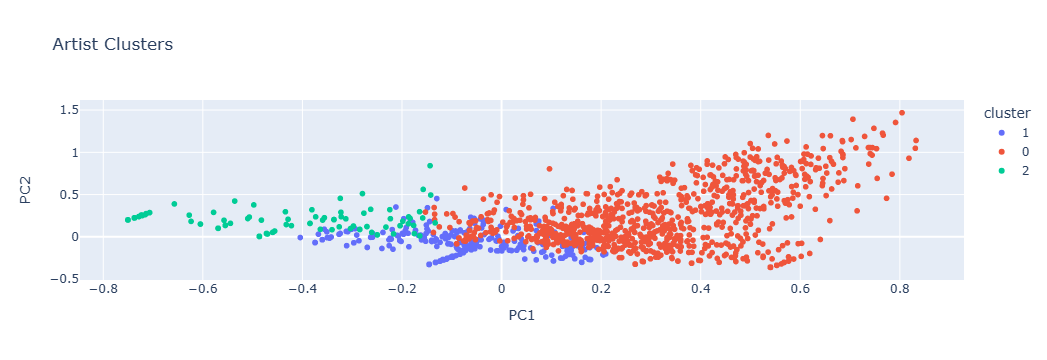

In [ ]:
# Observing whether clusters are distinguishable in 2d PC space.
from sklearn.decomposition import PCA
import plotly.express as px

# Reduce to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Build plot dataframe
plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'cluster': kmeans.labels_.astype(str),
    'artist_name': scaled_df['artist_name'],
    'superfan_score': scaled_df['superfan_score']
})

# Plot
fig = px.scatter(plot_df, x='PC1', y='PC2', color='cluster',
                 hover_data=['artist_name', 'superfan_score'],
                 title='Artist Clusters')
fig.show()

In [ ]:
# Observing statistical values. Not used as they prioritized features where the artists were non-null
labels = kmeans.labels_

for feature in X.columns:
    group0 = X[labels == 0][feature]
    group1 = X[labels == 1][feature]
    group2 = X[labels == 2][feature]
    
    stat, p = stats.kruskal(group0, group1, group2)
    print(f"{feature}: statistic = {stat:.2f}, p-value = {p:.2e}")

log_play_count_per_artist: statistic = 651.32, p-value = 3.69e-142
log_num_unique_songs_for_artist: statistic = 381.77, p-value = 1.26e-83
log_completion_rate: statistic = 2081.86, p-value = 0.00e+00
log_intentional_listening_rate: statistic = 1486.48, p-value = 0.00e+00
log_listening_consistency: statistic = 381.31, p-value = 1.58e-83
log_num_true_albums: statistic = 210.46, p-value = 1.99e-46
log_revisit_rate: statistic = 452.85, p-value = 4.63e-99
superfan_score: statistic = 330.25, p-value = 1.93e-72


In [26]:
scaled_df['cluster'] = kmeans.labels_
scaled_df.groupby('cluster')['cluster'].value_counts()

cluster
0    1326
1     866
2     541
Name: count, dtype: int64

In [ ]:
conn.execute("CREATE TABLE superfan_scores AS " \
" SELECT *, ROW_NUMBER() OVER (ORDER BY superfan_score DESC) AS rank" \
" FROM scaled_df")